<a href="https://colab.research.google.com/github/virenmarcellya12/Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_Praktikum_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama Anggota Kelompok 4:

-	Haniyathul Husna (M0501251011)
-	Siti Zakiah (M0501251044)
-	Viren Marcellya Clarenda Siboro (M0501251047)


##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.


In [62]:
import numpy as np

np.random.seed(11+44+47)

MA(1)

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore")

np.random.seed(11+44+47)

In [64]:
from sklearn.metrics import mean_squared_error

def rmse(y_actual, y_forecast):
    return np.sqrt(mean_squared_error(y_actual, y_forecast))


def mape(y_actual, y_forecast):
    y_actual = np.asarray(y_actual)
    y_forecast = np.asarray(y_forecast)

    mask = y_actual != 0

    return np.mean(
        np.abs(
            (y_actual[mask] - y_forecast[mask]) /
            y_actual[mask]
        )
    ) * 100

##SIMULASI MA(1)

In [65]:
np.random.seed(11+44+47)

n_ma = 120
theta = 0.6

eps = np.random.normal(size=n_ma)

ma1 = np.zeros(n_ma)

for t in range(n_ma):
    if t == 0:
        ma1[t] = eps[t]
    else:
        ma1[t] = eps[t] + theta * eps[t-1]

ma1 = pd.Series(ma1, name="MA1")

print(ma1.head())

0    1.668068
1    1.926703
2    1.613514
3   -0.285541
4    0.747545
Name: MA1, dtype: float64


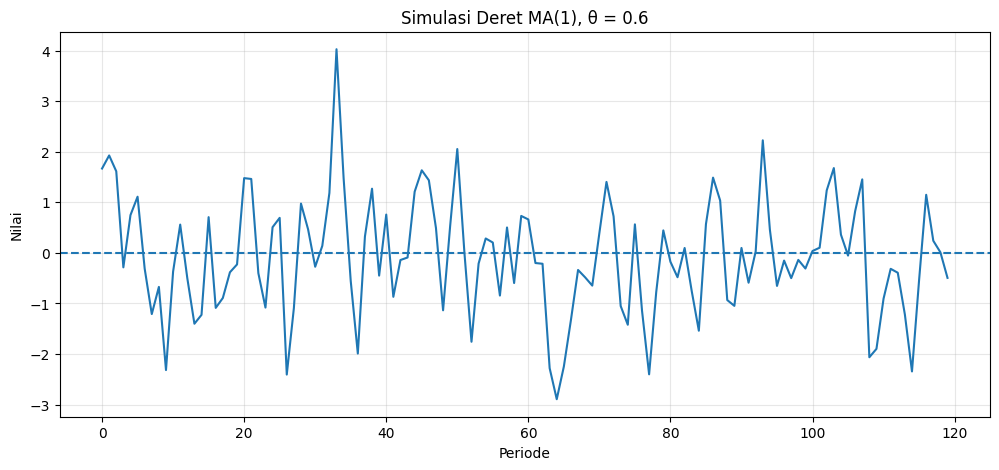

In [66]:
#PLOT DERET MA(1)
plt.figure(figsize=(12,5))

plt.plot(ma1)

plt.axhline(0, linestyle='--')

plt.title("Simulasi Deret MA(1), θ = 0.6")
plt.xlabel("Periode")
plt.ylabel("Nilai")

plt.grid(alpha=0.3)
plt.show()

###Pembagian Train-Test MA(1)

In [67]:
train_size_ma = int(len(ma1) * 0.80)

train_ma = ma1.iloc[:train_size_ma]
test_ma = ma1.iloc[train_size_ma:]

print("Jumlah data train:", len(train_ma))
print("Jumlah data test :", len(test_ma))

Jumlah data train: 96
Jumlah data test : 24


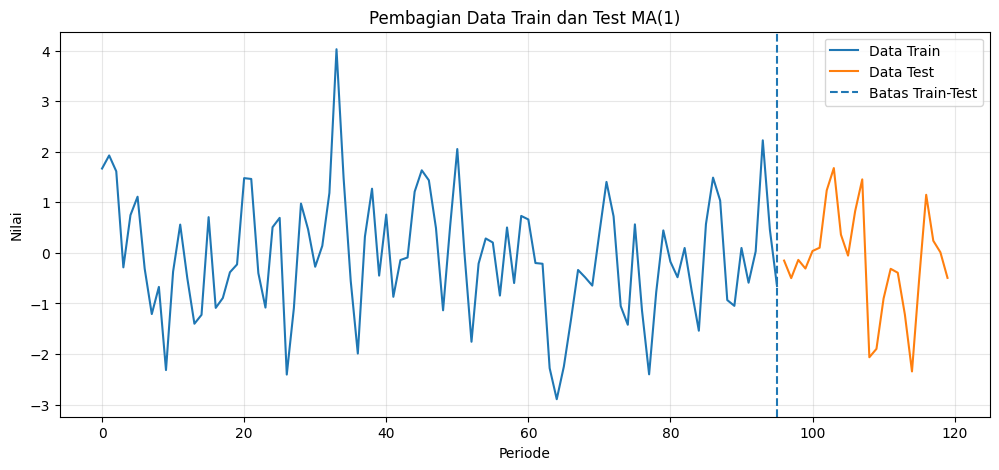

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    train_ma.index,
    train_ma,
    label="Data Train"
)

plt.plot(
    test_ma.index,
    test_ma,
    label="Data Test"
)

plt.axvline(
    train_size_ma - 1,
    linestyle='--',
    label="Batas Train-Test"
)

plt.title("Pembagian Data Train dan Test MA(1)")
plt.xlabel("Periode")
plt.ylabel("Nilai")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

###ACF, PACF dan EACF

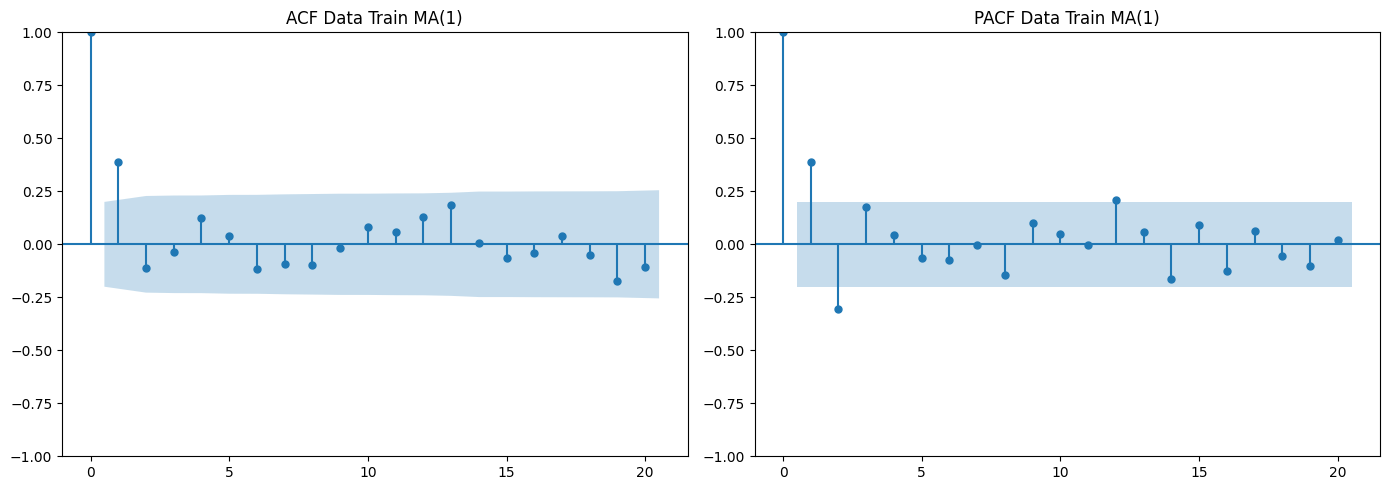

In [69]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(
    1, 2,
    figsize=(14,5)
)

plot_acf(
    train_ma,
    lags=20,
    ax=ax[0]
)

ax[0].set_title("ACF Data Train MA(1)")

plot_pacf(
    train_ma,
    lags=20,
    method='ywm',
    ax=ax[1]
)

ax[1].set_title("PACF Data Train MA(1)")

plt.tight_layout()
plt.show()

In [70]:
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.ar_model import AutoReg


def eacf_table(data, p_max=5, q_max=5):
    """
    Membuat tabel Extended Autocorrelation Function (EACF).

    Parameter:
    data  : data deret waktu
    p_max : maksimum orde AR
    q_max : maksimum orde MA

    Output:
    - tabel simbol 'x' dan 'o'
    - tabel nilai EACF
    """

    # -----------------------------------
    # 1. Persiapan data
    # -----------------------------------
    x = np.asarray(
        pd.Series(data).dropna(),
        dtype=float
    )

    # Centering data
    x = x - np.mean(x)

    P = p_max + 1
    Q = q_max + 1

    nar = P - 1
    nma = Q

    ncov = nar + nma + 2
    nrow = nar + nma + 1
    ncol = nrow - 1


    # -----------------------------------
    # 2. Membuat lag matrix
    # -----------------------------------
    lag_matrix = np.empty(
        (len(x), nar)
    )

    for j in range(nar):

        lag_matrix[:, j] = (
            pd.Series(x)
            .shift(j + 1)
            .to_numpy()
        )


    # -----------------------------------
    # 3. Menghitung ACF awal
    # -----------------------------------
    r = acf(
        x,
        nlags=ncov,
        fft=False
    )

    r_symmetric = np.r_[
        r[1:][::-1],
        r
    ]

    center = ncov + 1


    # -----------------------------------
    # 4. Estimasi model AR
    # -----------------------------------
    M = np.zeros(
        (nrow, ncol)
    )

    for k in range(
        1,
        ncol + 1
    ):

        model_ar = AutoReg(
            x,
            lags=k,
            trend='c'
        ).fit()

        M[:k, k - 1] = (
            model_ar.params[1:]
        )


    # -----------------------------------
    # 5. Fungsi update matrix
    # -----------------------------------
    def update_matrix(A):

        rows, cols = A.shape

        B = np.empty(
            (rows, cols - 1)
        )

        for j in range(
            cols - 1
        ):

            j1 = j + 1

            shifted = (
                pd.Series(A[:, j])
                .shift(1)
                .to_numpy()
            )

            shifted[0] = -1

            temp = (
                A[:, j1]
                - shifted
                * A[j1, j1]
                / A[j, j]
            )

            temp[j1] = 0

            B[:, j] = temp

        return B


    # -----------------------------------
    # 6. Menghitung nilai EACF
    # -----------------------------------
    E = np.empty(
        (P, Q)
    )

    current = M.copy()


    for q_index in range(Q):

        current = update_matrix(
            current
        )

        lag = q_index + 1

        values = np.zeros(P)


        # p = 0
        values[0] = (
            r_symmetric[
                center + lag - 1
            ]
        )


        # p > 0
        for p in range(
            1,
            P
        ):

            A = np.column_stack(
                (
                    x[p:],
                    lag_matrix[p:, :p]
                )
            )

            b = np.r_[
                1,
                -current[:p, p - 1]
            ]

            residual = A @ b


            values[p] = acf(
                residual,
                nlags=lag,
                fft=False
            )[lag]


        E[:, q_index] = values


    # -----------------------------------
    # 7. Menentukan simbol x dan o
    # -----------------------------------
    n_eff = (
        len(x)
        - np.arange(
            1,
            P + 1
        )
        + 1
    )

    symbol = np.empty(
        E.shape,
        dtype=object
    )


    for q_index in range(Q):

        n_eff = n_eff - 1

        batas = (
            2 / np.sqrt(n_eff)
        )

        symbol[:, q_index] = np.where(
            np.abs(E[:, q_index]) > batas,
            'x',
            'o'
        )


    # -----------------------------------
    # 8. Membuat dataframe
    # -----------------------------------
    symbol_table = pd.DataFrame(
        symbol,
        index=[
            f"AR({i})"
            for i in range(P)
        ],
        columns=[
            f"MA({j})"
            for j in range(Q)
        ]
    )


    value_table = pd.DataFrame(
        E,
        index=[
            f"AR({i})"
            for i in range(P)
        ],
        columns=[
            f"MA({j})"
            for j in range(Q)
        ]
    )


    return symbol_table, value_table


# ======================================
# EACF DATA LATIH MA(1)
# ======================================

eacf_symbol, eacf_value = eacf_table(
    train_ma,
    p_max=5,
    q_max=5
)


print("EACF Data Latih MA(1)")
print("x = signifikan")
print("o = tidak signifikan")
print()

display(eacf_symbol)

EACF Data Latih MA(1)
x = signifikan
o = tidak signifikan



,MA(0),MA(1),MA(2),MA(3),MA(4),MA(5)
AR(0),x,o,o,o,o,o
AR(1),x,x,o,o,o,o
AR(2),x,o,o,o,o,o
AR(3),x,x,o,o,o,o
AR(4),x,x,o,o,o,o
AR(5),x,x,o,o,o,o


###Fitting Kandidat MA(1)

In [71]:
candidate_ma = [
    (0,0,0),
    (1,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,0),
    (0,0,2),
    (2,0,1),
    (1,0,2)
]

In [72]:
results_ma = []

for order in candidate_ma:

    try:
        model = ARIMA(
            train_ma,
            order=order
        )

        fit = model.fit()

        results_ma.append({
            "Model": f"ARIMA{order}",
            "AIC": fit.aic,
            "BIC": fit.bic
        })

    except:
        pass

results_ma = pd.DataFrame(results_ma)

results_ma.sort_values("AIC")

,Model,AIC,BIC
2,"ARIMA(0, 0, 1)",284.811035,292.504080
5,"ARIMA(0, 0, 2)",286.734958,296.992350
3,"ARIMA(1, 0, 1)",286.757807,297.015200
4,"ARIMA(2, 0, 0)",287.532739,297.790132
6,"ARIMA(2, 0, 1)",287.568780,300.390521
7,"ARIMA(1, 0, 2)",288.544040,301.365781
1,"ARIMA(1, 0, 0)",294.978550,302.671595
0,"ARIMA(0, 0, 0)",308.770154,313.898850


###Diagnostik Residual

In [73]:
best_model_ma = ARIMA(
    train_ma,
    order=(0, 0, 1)
).fit()

# Residual model
resid_ma = best_model_ma.resid

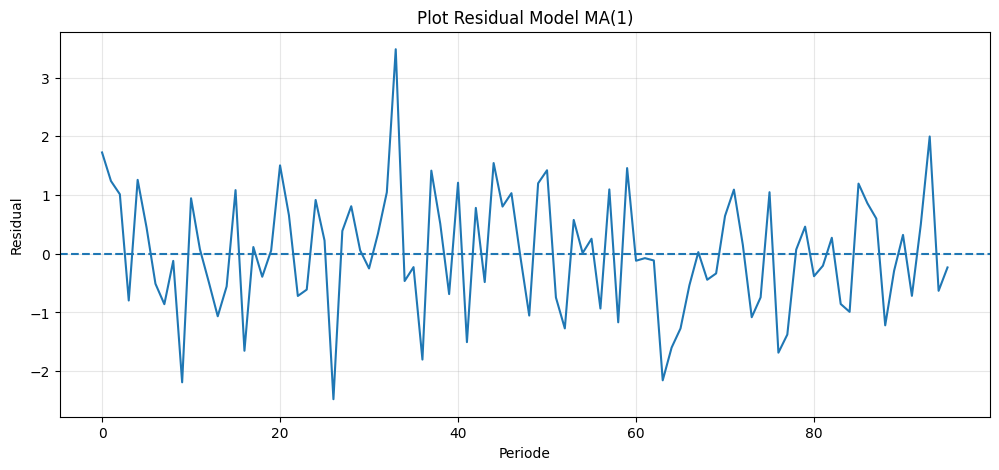

In [74]:
plt.figure(figsize=(12, 5))

plt.plot(resid_ma)

plt.axhline(
    0,
    linestyle='--'
)

plt.title("Plot Residual Model MA(1)")
plt.xlabel("Periode")
plt.ylabel("Residual")

plt.grid(alpha=0.3)
plt.show()

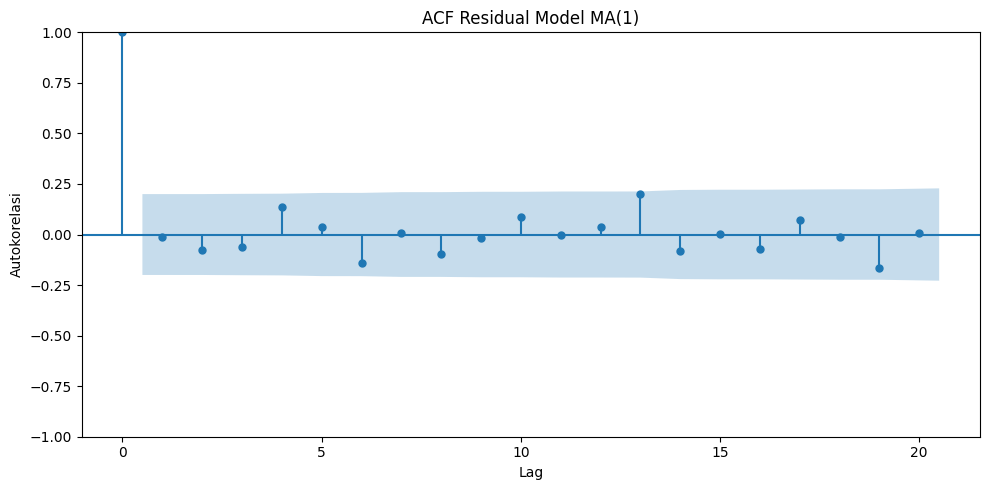

In [75]:
plt.figure(figsize=(10, 5))

plot_acf(
    resid_ma,
    lags=20,
    ax=plt.gca()
)

plt.title("ACF Residual Model MA(1)")
plt.xlabel("Lag")
plt.ylabel("Autokorelasi")

plt.tight_layout()
plt.show()



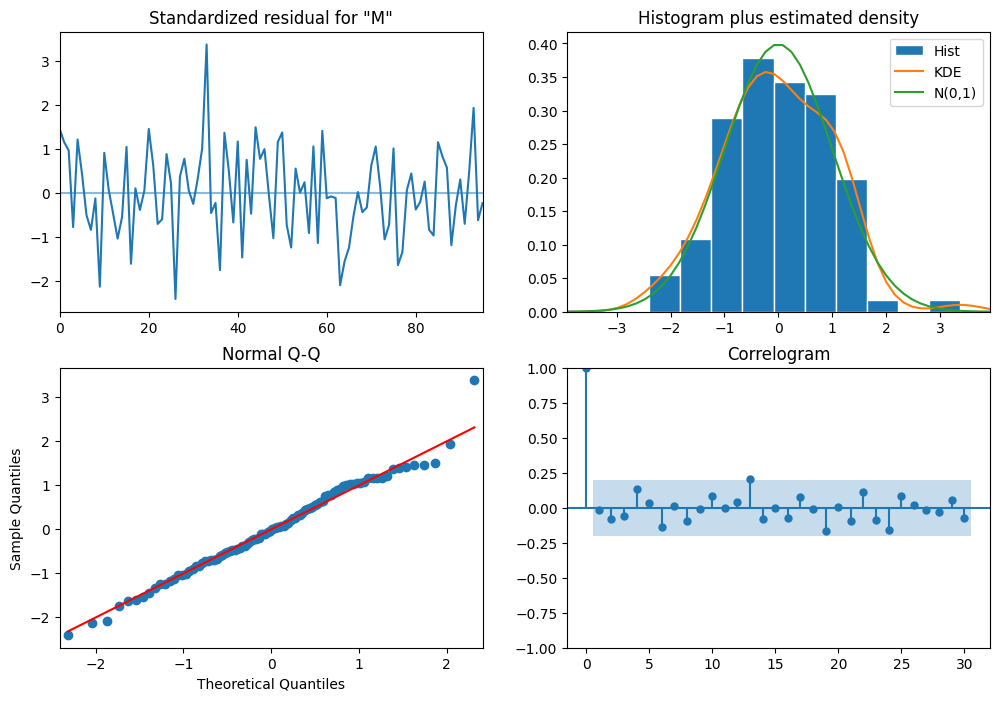

In [76]:
from statsmodels.tsa.arima.model import ARIMA

model_ma1 = ARIMA(
    train_ma,
    order=(0, 0, 1)
).fit()

# Diagnostik sisaan model MA(1)

model_ma1.plot_diagnostics(
    figsize=(12, 8),
    lags=30
)

plt.show()

Ljung-Box

In [77]:
ljung_ma = acorr_ljungbox(
    resid_ma,
    lags=[10, 20],
    return_df=True
)

ljung_ma

,lb_stat,lb_pvalue
10,6.840697,0.740394
20,16.893557,0.659874


###Forecast MA(1)

In [78]:
forecast_ma = best_model_ma.forecast(
    steps=len(test_ma)
)

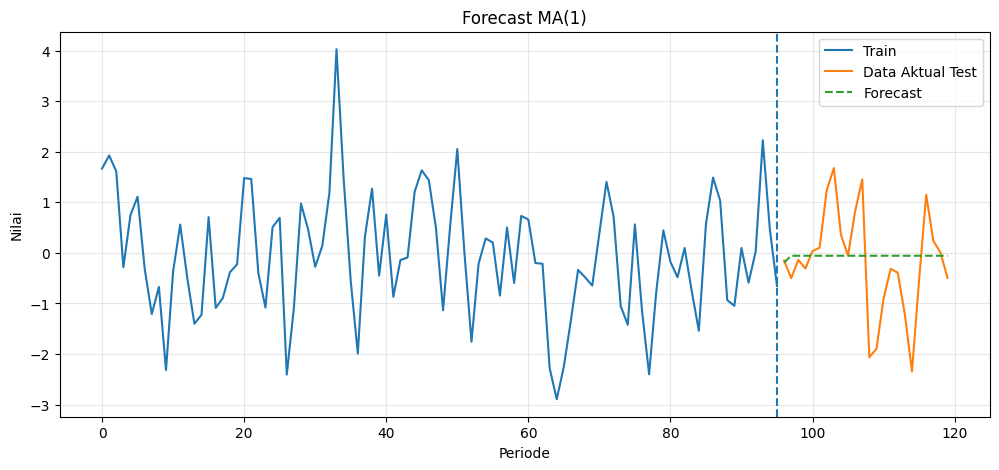

In [79]:
plt.figure(figsize=(12,5))

plt.plot(
    train_ma.index,
    train_ma,
    label="Train"
)

plt.plot(
    test_ma.index,
    test_ma,
    label="Data Aktual Test"
)

plt.plot(
    test_ma.index,
    forecast_ma,
    linestyle='--',
    label="Forecast"
)

plt.axvline(
    train_size_ma - 1,
    linestyle='--'
)

plt.title("Forecast MA(1)")
plt.xlabel("Periode")
plt.ylabel("Nilai")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

###Evaluasi MA(1)

In [80]:
rmse_test_ma = rmse(
    test_ma,
    forecast_ma
)

mape_test_ma = mape(
    test_ma,
    forecast_ma
)

print("RMSE Test:", rmse_test_ma)
print("MAPE Test:", mape_test_ma, "%")

RMSE Test: 1.0220382110533461
MAPE Test: 117.4510466473009 %


In [81]:
fitted_ma = best_model_ma.fittedvalues

rmse_train_ma = rmse(
    train_ma.iloc[1:],
    fitted_ma.iloc[1:]
)

mape_train_ma = mape(
    train_ma.iloc[1:],
    fitted_ma.iloc[1:]
)

print("RMSE Train:", rmse_train_ma)
print("MAPE Train:", mape_train_ma, "%")

RMSE Train: 1.0263861011631588
MAPE Train: 184.54042600454048 %


##AR(2)

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# Seed kelompok
np.random.seed(11+44+47)

# Parameter AR(2)
n_ar = 100
phi1 = 0.9
phi2 = -0.5

# Error acak
eps_ar = np.random.normal(
    loc=0,
    scale=1,
    size=n_ar
)

# Membuat deret AR(2)
ar2 = np.zeros(n_ar)

for t in range(2, n_ar):
    ar2[t] = (
        phi1 * ar2[t-1]
        + phi2 * ar2[t-2]
        + eps_ar[t]
    )

ar2 = pd.Series(
    ar2,
    name="AR2"
)

print(ar2.head())

0    0.000000
1    0.000000
2    1.057997
3    0.031858
4    0.799422
Name: AR2, dtype: float64


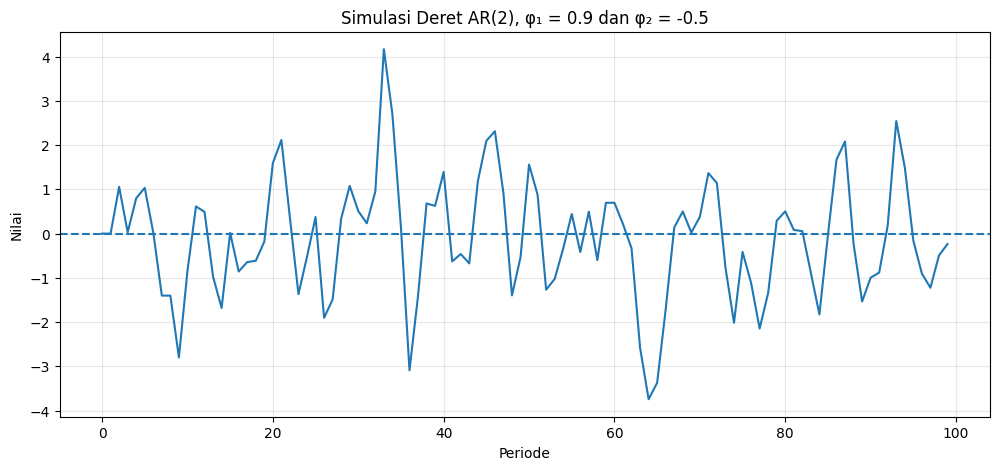

In [83]:
plt.figure(figsize=(12,5))

plt.plot(
    ar2,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Simulasi Deret AR(2), φ₁ = 0.9 dan φ₂ = -0.5'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.grid(alpha=0.3)

plt.show()

###Pembagian Data Train dan Test

In [84]:
train_size_ar = int(
    len(ar2) * 0.80
)

train_ar = ar2.iloc[
    :train_size_ar
]

test_ar = ar2.iloc[
    train_size_ar:
]

print("Jumlah data train:", len(train_ar))
print("Jumlah data test :", len(test_ar))

Jumlah data train: 80
Jumlah data test : 20


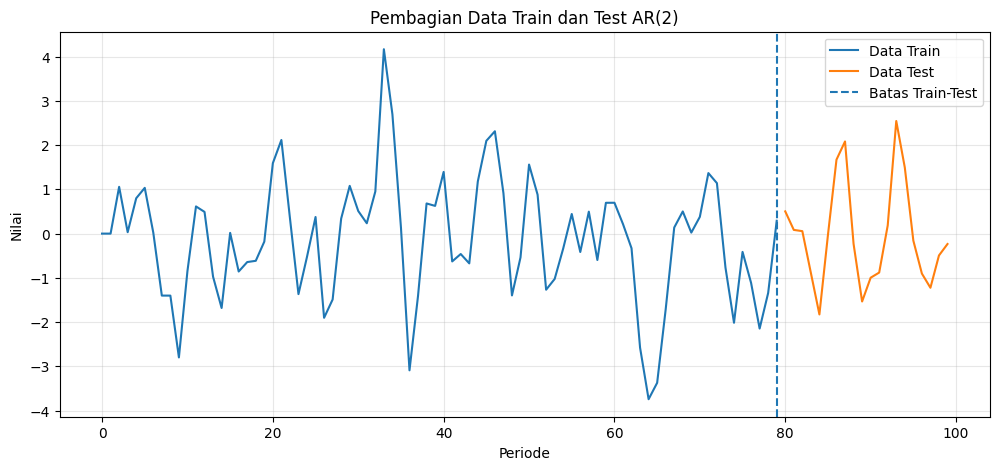

In [85]:
plt.figure(figsize=(12,5))

plt.plot(
    train_ar.index,
    train_ar,
    label='Data Train'
)

plt.plot(
    test_ar.index,
    test_ar,
    label='Data Test'
)

plt.axvline(
    train_size_ar - 1,
    linestyle='--',
    label='Batas Train-Test'
)

plt.title(
    'Pembagian Data Train dan Test AR(2)'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

###ACF, PACF dan EACF AR(2)

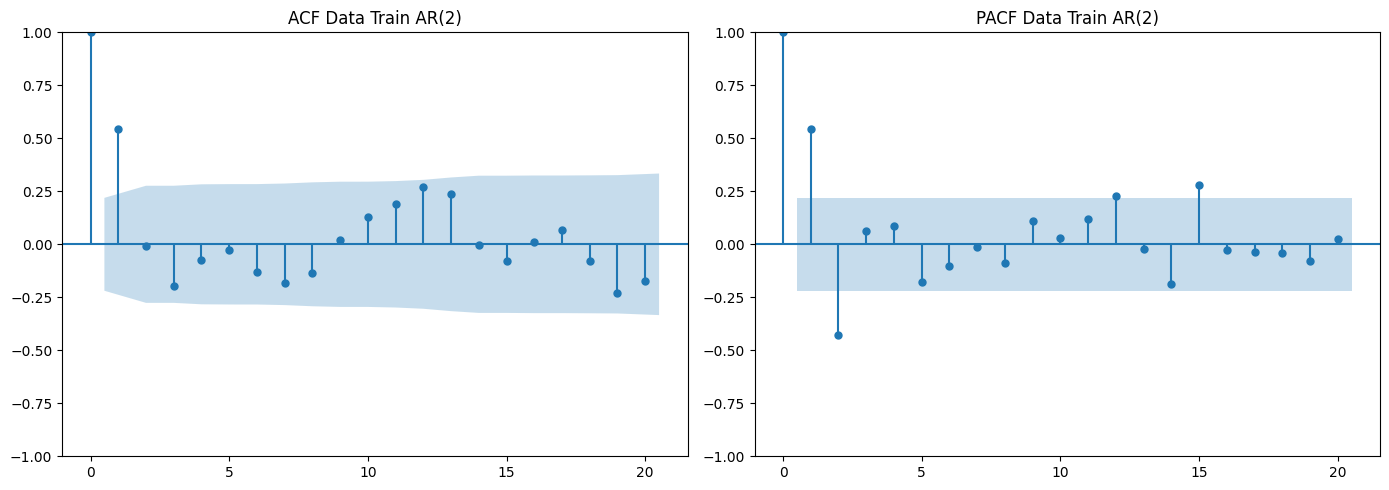

In [86]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

plot_acf(
    train_ar,
    lags=20,
    ax=ax[0]
)

ax[0].set_title(
    'ACF Data Train AR(2)'
)

plot_pacf(
    train_ar,
    lags=20,
    method='ywm',
    ax=ax[1]
)

ax[1].set_title(
    'PACF Data Train AR(2)'
)

plt.tight_layout()
plt.show()

In [87]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg


def eacf_python(x, ar_max=5, ma_max=5):

    # Ubah data menjadi array numerik
    x = np.asarray(x, dtype=float)

    # Hilangkan missing value
    x = x[~np.isnan(x)]

    n = len(x)

    # Matriks nilai EACF
    eacf_values = np.full(
        (ar_max + 1, ma_max + 1),
        np.nan
    )

    for p in range(ar_max + 1):

        # Jika p = 0, gunakan data asli
        if p == 0:
            residual = x.copy()

        # Jika p > 0, fit AR(p)
        else:
            try:
                model = AutoReg(
                    x,
                    lags=p,
                    trend='c'
                )

                fit = model.fit()

                residual = np.asarray(
                    fit.resid,
                    dtype=float
                )

            except Exception as e:
                print(f"AR({p}) gagal: {e}")
                continue

        residual = residual[~np.isnan(residual)]

        # Hitung korelasi residual
        for q in range(ma_max + 1):

            if q == 0:
                eacf_values[p, q] = 1

            else:
                if len(residual) > q:

                    r = np.corrcoef(
                        residual[q:],
                        residual[:-q]
                    )[0, 1]

                    eacf_values[p, q] = r

    # Batas signifikansi
    bound = 1.96 / np.sqrt(n)

    # Membuat tabel simbol
    eacf_symbol = pd.DataFrame(
        "",
        index=range(ar_max + 1),
        columns=range(ma_max + 1)
    )

    for p in range(ar_max + 1):

        for q in range(ma_max + 1):

            value = eacf_values[p, q]

            if np.isnan(value):
                eacf_symbol.iloc[p, q] = "-"

            elif abs(value) <= bound:
                eacf_symbol.iloc[p, q] = "O"

            else:
                eacf_symbol.iloc[p, q] = "X"

    # Nama baris dan kolom
    eacf_symbol.index.name = "AR (p)"
    eacf_symbol.columns.name = "MA (q)"

    return eacf_symbol

In [88]:
eacf_ar2 = eacf_python(
    train_ar,
    ar_max=5,
    ma_max=5
)

print("Tabel EACF AR(2):")
display(eacf_ar2)

Tabel EACF AR(2):


MA (q),0,1,2,3,4,5
AR (p),,,,,,
0,X,X,O,O,O,O
1,X,X,X,X,O,O
2,X,O,O,O,O,O
3,X,O,O,O,O,O
4,X,O,O,O,O,O
5,X,O,O,O,O,O


###Kandidat Model AR(2)

In [89]:
candidate_ar = [
    (0,0,0),
    (1,0,0),
    (2,0,0),
    (3,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,1),
    (1,0,2),
    (2,0,2)
]

In [90]:
results_ar = []

for order in candidate_ar:

    try:

        model = ARIMA(
            train_ar,
            order=order
        )

        fit = model.fit()

        results_ar.append({
            'Model': f'ARIMA{order}',
            'AIC': fit.aic,
            'BIC': fit.bic
        })

        print(
            f"ARIMA{order} berhasil | "
            f"AIC = {fit.aic:.3f} | "
            f"BIC = {fit.bic:.3f}"
        )

    except Exception as e:

        print(
            f"ARIMA{order} gagal: {e}"
        )

ARIMA(0, 0, 0) berhasil | AIC = 281.808 | BIC = 286.572
ARIMA(1, 0, 0) berhasil | AIC = 256.183 | BIC = 263.329
ARIMA(2, 0, 0) berhasil | AIC = 241.900 | BIC = 251.428
ARIMA(3, 0, 0) berhasil | AIC = 243.610 | BIC = 255.520
ARIMA(0, 0, 1) berhasil | AIC = 248.009 | BIC = 255.155
ARIMA(1, 0, 1) berhasil | AIC = 246.711 | BIC = 256.239
ARIMA(2, 0, 1) berhasil | AIC = 243.706 | BIC = 255.616
ARIMA(1, 0, 2) berhasil | AIC = 243.302 | BIC = 255.212
ARIMA(2, 0, 2) berhasil | AIC = 239.927 | BIC = 254.219


In [91]:
results_ar = pd.DataFrame(
    results_ar
)

results_ar = results_ar.sort_values(
    by='AIC'
)

results_ar

,Model,AIC,BIC
8,"ARIMA(2, 0, 2)",239.927289,254.219448
2,"ARIMA(2, 0, 0)",241.899513,251.427620
7,"ARIMA(1, 0, 2)",243.302262,255.212396
3,"ARIMA(3, 0, 0)",243.610042,255.520175
6,"ARIMA(2, 0, 1)",243.706227,255.616360
5,"ARIMA(1, 0, 1)",246.711223,256.239329
4,"ARIMA(0, 0, 1)",248.008965,255.155045
1,"ARIMA(1, 0, 0)",256.183231,263.329311
0,"ARIMA(0, 0, 0)",281.808273,286.572327


###Pemilihan model AIC dan BIC

In [92]:
best_aic_ar = results_ar.loc[
    results_ar['AIC'].idxmin()
]

best_bic_ar = results_ar.loc[
    results_ar['BIC'].idxmin()
]

print("Model terbaik berdasarkan AIC:")
print(best_aic_ar)

print("\nModel terbaik berdasarkan BIC:")
print(best_bic_ar)

Model terbaik berdasarkan AIC:
Model    ARIMA(2, 0, 2)
AIC          239.927289
BIC          254.219448
Name: 8, dtype: object

Model terbaik berdasarkan BIC:
Model    ARIMA(2, 0, 0)
AIC          241.899513
BIC           251.42762
Name: 2, dtype: object


###Fit Model AR(2)

In [93]:
model_ar2 = ARIMA(
    train_ar,
    order=(2,0,0)
)

fit_ar2 = model_ar2.fit()

print(
    fit_ar2.summary()
)

                               SARIMAX Results                                
Dep. Variable:                    AR2   No. Observations:                   80
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -116.950
Date:                Wed, 23 Sep 2026   AIC                            241.900
Time:                        04:02:59   BIC                            251.428
Sample:                             0   HQIC                           245.720
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1299      0.180     -0.723      0.469      -0.482       0.222
ar.L1          0.7737      0.116      6.695      0.000       0.547       1.000
ar.L2         -0.4278      0.114     -3.742      0.0

###Diagnostik Residual AR(2)

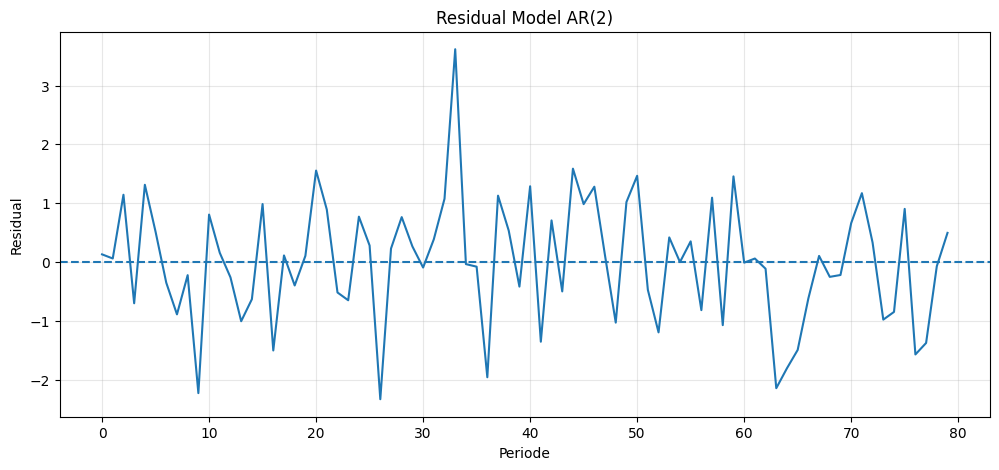

In [94]:
resid_ar = fit_ar2.resid

plt.figure(figsize=(12,5))

plt.plot(
    resid_ar
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Residual Model AR(2)'
)

plt.xlabel('Periode')
plt.ylabel('Residual')

plt.grid(alpha=0.3)

plt.show()

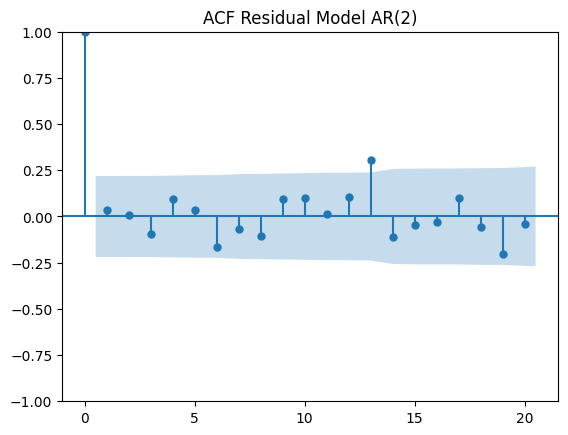

In [95]:
plot_acf(
    resid_ar,
    lags=20
)

plt.title(
    'ACF Residual Model AR(2)'
)

plt.show()

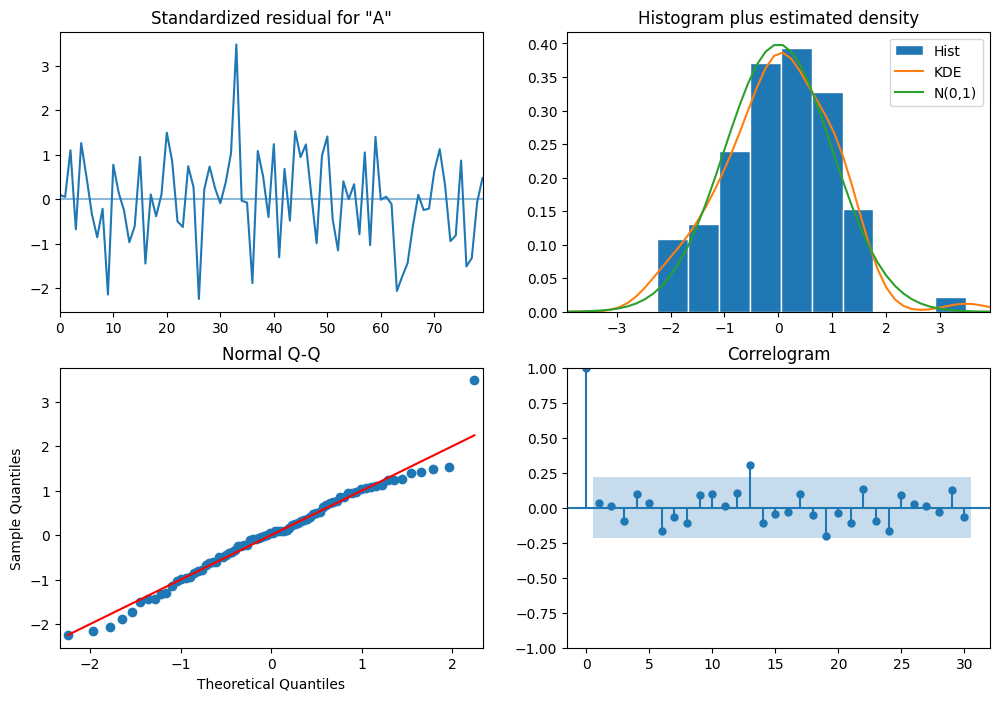

In [97]:
model_ar2 = ARIMA(
    train_ar,
    order=(2, 0, 0)
).fit()
# Diagnostik sisaan model AR(2)

model_ar2.plot_diagnostics(
    figsize=(12, 8),
    lags=30
)

plt.show()

L-jung-Box

In [ ]:
ljung_ar = acorr_ljungbox(
    resid_ar,
    lags=[10, 20],
    return_df=True
)

print(ljung_ar)

###Forecast AR(2)

In [ ]:
forecast_ar = fit_ar2.forecast(
    steps=len(test_ar)
)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    train_ar.index,
    train_ar,
    label='Data Train'
)

plt.plot(
    test_ar.index,
    test_ar,
    label='Data Aktual Test'
)

plt.plot(
    test_ar.index,
    forecast_ar,
    linestyle='--',
    label='Forecast AR(2)'
)

plt.axvline(
    train_size_ar - 1,
    linestyle='--',
    label='Batas Train-Test'
)

plt.title(
    'Peramalan Deret AR(2)'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

###Evaluasi AR(2)

In [ ]:
def RMSE(y_actual, y_pred):
    return np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )


def MAPE(y_actual, y_pred):

    y_actual = np.asarray(y_actual)
    y_pred = np.asarray(y_pred)

    mask = y_actual != 0

    return np.mean(
        np.abs(
            (y_actual[mask] - y_pred[mask])
            / y_actual[mask]
        )
    ) * 100

In [ ]:
rmse_test_ar = RMSE(
    test_ar,
    forecast_ar
)

mape_test_ar = MAPE(
    test_ar,
    forecast_ar
)

print(
    "RMSE Test AR(2):",
    rmse_test_ar
)

print(
    "MAPE Test AR(2):",
    mape_test_ar,
    "%"
)

In [ ]:
fitted_ar = fit_ar2.fittedvalues

rmse_train_ar = RMSE(
    train_ar.iloc[2:],
    fitted_ar.iloc[2:]
)

mape_train_ar = MAPE(
    train_ar.iloc[2:],
    fitted_ar.iloc[2:]
)

print(
    "RMSE Train AR(2):",
    rmse_train_ar
)

print(
    "MAPE Train AR(2):",
    mape_train_ar,
    "%"
)

##ARMA (1,1)

In [ ]:
np.random.seed(11+44+47)

n_arma = 200

phi = 0.4
theta = 0.6

eps_arma = np.random.normal(
    0,
    1,
    n_arma
)

arma11 = np.zeros(n_arma)

for t in range(1, n_arma):

    arma11[t] = (
        phi * arma11[t-1]
        + eps_arma[t]
        + theta * eps_arma[t-1]
    )

arma11 = pd.Series(
    arma11,
    name='ARMA11'
)

print(arma11.head())

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    arma11
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Simulasi Deret ARMA(1,1), φ = 0.4 dan θ = 0.6'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
train_size_arma = int(
    len(arma11) * 0.80
)

train_arma = arma11.iloc[
    :train_size_arma
]

test_arma = arma11.iloc[
    train_size_arma:
]

print(
    "Jumlah data train:",
    len(train_arma)
)

print(
    "Jumlah data test:",
    len(test_arma)
)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    train_arma.index,
    train_arma,
    label='Data Train'
)

plt.plot(
    test_arma.index,
    test_arma,
    label='Data Test'
)

plt.axvline(
    train_size_arma - 1,
    linestyle='--',
    label='Batas Train-Test'
)

plt.title(
    'Pembagian Data Train dan Test ARMA(1,1)'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Plot ACF, PACF, EACF ARMA (1,1)

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

plot_acf(
    train_arma,
    lags=30,
    ax=ax[0]
)

ax[0].set_title(
    'ACF Data Train ARMA(1,1)'
)

plot_pacf(
    train_arma,
    lags=30,
    method='ywm',
    ax=ax[1]
)

ax[1].set_title(
    'PACF Data Train ARMA(1,1)'
)

plt.tight_layout()
plt.show()

In [ ]:
eacf_arma11 = eacf_python(
    train_arma,
    ar_max=5,
    ma_max=5
)

print("Tabel EACF ARMA(1,1):")
display(eacf_arma11)

###Kandidat ARMA (1,1)

In [ ]:
candidate_arma = [
    (0,0,0),
    (1,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,0),
    (0,0,2),
    (2,0,1),
    (1,0,2),
    (2,0,2)
]

In [ ]:
results_arma = []

for order in candidate_arma:

    try:

        model = ARIMA(
            train_arma,
            order=order
        )

        fit = model.fit()

        results_arma.append({
            'Model': f'ARIMA{order}',
            'AIC': fit.aic,
            'BIC': fit.bic
        })

        print(
            f"ARIMA{order} berhasil | "
            f"AIC = {fit.aic:.3f} | "
            f"BIC = {fit.bic:.3f}"
        )

    except Exception as e:

        print(
            f"ARIMA{order} gagal: {e}"
        )

In [ ]:
results_arma = pd.DataFrame(
    results_arma
)

results_arma = results_arma.sort_values(
    by='AIC'
)

results_arma

###Model terbaik AIC dan BIC

In [ ]:
best_aic_arma = results_arma.loc[
    results_arma['AIC'].idxmin()
]

best_bic_arma = results_arma.loc[
    results_arma['BIC'].idxmin()
]

print("Model terbaik berdasarkan AIC:")
print(best_aic_arma)

print("\nModel terbaik berdasarkan BIC:")
print(best_bic_arma)

In [ ]:
model_arma11 = ARIMA(
    train_arma,
    order=(1,0,1)
)

fit_arma11 = model_arma11.fit()

print(
    fit_arma11.summary()
)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

model_arma11 = ARIMA(
    train_arma,
    order=(1, 0, 1)
).fit()
# Analisis sisaan model ARMA(1,1)

model_arma11.plot_diagnostics(
    figsize=(12, 8),
    lags=30
)

plt.show()

###Diagnostik Residual

In [ ]:
resid_arma = fit_arma11.resid

plt.figure(figsize=(12,5))

plt.plot(
    resid_arma
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Residual Model ARMA(1,1)'
)

plt.xlabel('Periode')
plt.ylabel('Residual')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
plot_acf(
    resid_arma,
    lags=30
)

plt.title(
    'ACF Residual Model ARMA(1,1)'
)

plt.show()

L-Jung Box

In [ ]:
ljung_arma = acorr_ljungbox(
    resid_arma,
    lags=[10,20],
    return_df=True
)

print(ljung_arma)

###Forecast ARMA(1,1)

In [ ]:
forecast_arma = fit_arma11.forecast(
    steps=len(test_arma)
)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    train_arma.index,
    train_arma,
    label='Data Train'
)

plt.plot(
    test_arma.index,
    test_arma,
    label='Data Aktual Test'
)

plt.plot(
    test_arma.index,
    forecast_arma,
    linestyle='--',
    label='Forecast ARMA(1,1)'
)

plt.axvline(
    train_size_arma - 1,
    linestyle='--',
    label='Batas Train-Test'
)

plt.title(
    'Peramalan Deret ARMA(1,1)'
)

plt.xlabel('Periode')
plt.ylabel('Nilai')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

###Evaluasi ARMA (1,1)

In [ ]:
#TEST
rmse_test_arma = RMSE(
    test_arma,
    forecast_arma
)

mape_test_arma = MAPE(
    test_arma,
    forecast_arma
)

print(
    "RMSE Test ARMA(1,1):",
    rmse_test_arma
)

print(
    "MAPE Test ARMA(1,1):",
    mape_test_arma,
    "%"
)

In [ ]:
#TRAIN
fitted_arma = fit_arma11.fittedvalues

rmse_train_arma = RMSE(
    train_arma,
    fitted_arma
)

mape_train_arma = MAPE(
    train_arma,
    fitted_arma
)

print(
    "RMSE Train ARMA(1,1):",
    rmse_train_arma
)

print(
    "MAPE Train ARMA(1,1):",
    mape_train_arma,
    "%"
)